
<h1 style="font-family: 'Verdana'; color: purple;">Regressione lineare semplice</h1>

<h2 style="font-family: 'Verdana'; color: lightblue;">Introduzione</h2>

La regressione lineare semplice è il modello statistico/di ML più semplice. 

Andiamo ad analizzare ogni singola parola:
- Regressione: perchè lo scopo è prevedere un valore umerico continuo (classificazione per valori categorici)
- Lineare: perchè il modello cerca di trovare una retta (ovvero una relazione lineare) tra le variabili
- Semplice: perchè il modello coinvolge una sola variabile dipendente X

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
sns.set_theme()

Andremo a utilizzare un dataset presente di default su seaborn, che quindi possiamo direttamente caricare, chiamato "penguins". Contiene info relative ad alcune caratteristiche dei pinguini

In [4]:
df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Prima di procedere con l'analisi facciamo un minimo di pulizia dati, andando a rimuovere le righe contenente dei missing values

In [5]:
df[pd.isna(df.flipper_length_mm)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df[~pd.isna(df.flipper_length_mm)]

Ora procediamo con la creazione di uno scatterplot per vedere graficamente eventuali correlazioni tra le variabili

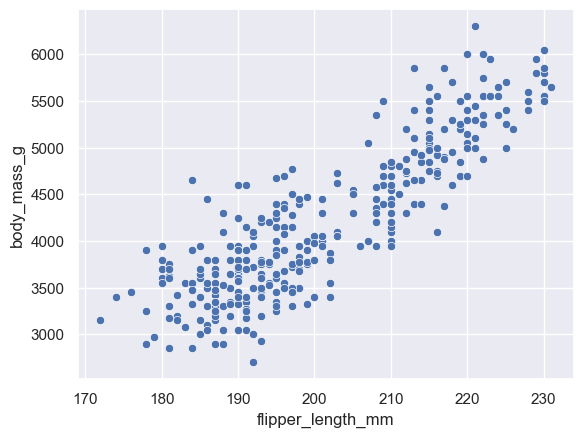

In [7]:
sns.scatterplot(x = "flipper_length_mm", y = "body_mass_g", data = df)
plt.show()

Appare subito evidente una correlazione positiva tra le due variabili. Calcoliamo tale correlazione:

In [8]:
correl = df.flipper_length_mm.corr(df.body_mass_g)
correl

0.8712017673060111

Perfetto, abbiamo quantificato la forza della relazione tra le due variabili. Però questo non ci basta. Vogliamo stimare quanto cambi la variabile Y al variare di un certo ammontare della variabile X.

Nel caso di una regressione lineare semplice questo è graficamente rappresentabile da una retta:

$y = b_0 + b_1X$

dove: 

- $X$ è chiamata variabile indipendente (o feature nel linguaggio del ML)
- $Y$ è chiamata variabile dipendente (o target nel linguaggio del ML)
- $b_0$ rappresenta l'intercetta(o costante)
- $b_1$ rappresenta la pendenza di $X$ (o coefficiente angolare). 


L'obettivo sarà identificare la retta di regressione che meglio si adatta ai nostri dati, ovvero la retta che minimizza la distanza tra i dati e la nostra retta

<h2 style="font-family: 'Verdana'; color: lightblue;">Metodo dei minimi quadrati</h2>

Come abbiamo detto, esistono potenzialmente infinite rette che passano attraverso i nostri punti. Proviamo a construirne una noi:

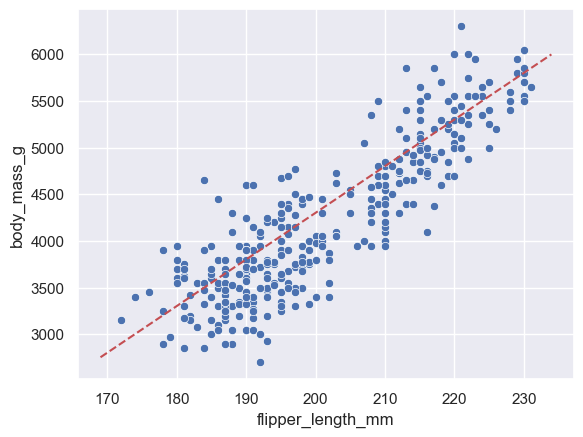

In [11]:
sns.scatterplot(x = "flipper_length_mm", y = "body_mass_g", data = df)

intercept = -5700
slope = 50

axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = intercept + slope*x_vals

plt.plot(x_vals, y_vals, "--", color = "r")
plt.show()

La retta effettivamente passa tra i nostri punti, ma non sappiamo se effettivamente sia la retta migliore. Per questo usiamo il metodo dei minimi quadrati

Il metodo dei minimi quadrati (OLS: Ordinary Least Squares) ha come obiettivo quello di minimizzare la somma dei quadrati dei residui, dove il residuo è definito come la differenza tra il valore osservato e il valore stimato dalla regressione (visivamente, la distanza tra il punto osservato e la retta stessa).

Aggiungiamo all'equazione della retta anche il componente dell'errore:

$$
Y = b_0 + b_1X + \epsilon \\
$$

$$
\rightarrow  \epsilon = Y - b_0 - b_1X 
$$

di conseguenza, l'OLS ha come obiettivo:

$$
    \begin{align*}
    &\min_{b_0, b_1} \sum_{i = 1}^{n} \epsilon^2 \\
    \rightarrow  &\min_{b_0, b_1} \sum_{i = 1}^{n} (Y - b_0 - b_1X)^2
    \end{align*}
$$

Tale funzione-obiettivo per essere risolta necessita di trovare i valori dei parametri $b_0$ e $b_1$ che minimizzano tale somma.
Matematicamente, ciò si ottiene facendo la derivata della funzione e ponendola uguale a 0 (punto di minimo).
Alla fine dei vari passaggi matematici, otteniamo le seguenti formule per il calcolo dei coefficienti:

$$
    \begin{align*}
    b_0 & = \overline{y} - b_1 \overline{x} \\
    b_1 & = \frac{\sum_{i=1}^{n} (x_i - \overline{x})(y_i - \overline{y})}{\sum_{i=1}^{n} (x_i - \overline{x})^2}
    \end{align*}
$$

dove $\overline{x}$ and $\overline{y}$ sono, rispettivamente, le medie campionarie di $x$ e $y$.

Proviamo quindi a farlo in codice Python calcolandoci manualmente i coefficienti (poi vedremo che esiste una funzione apposita che ci evita di fare tutti i passaggi):

In [13]:
def calcolo_coeff_reg_lin(x, y):
    
    #calcolo i valori medi di x e y osservati
    X_mean = np.mean(x)
    Y_mean = np.mean(y)
    
    #calcolo le deviazioni standard di x e y:
    X_mean_dev = [el - X_mean for el in x]
    Y_mean_dev = [el - Y_mean for el in y]
    
    #calcolo la covarianza tra X e Y e la varianza di X (numeratore e denominatore del coeff $b_1$)
    XY_covar = np.sum(np.array(X_mean_dev)*np.array(Y_mean_dev))
    X_var = np.sum(np.array(X_mean_dev)**2)
    
    #calcolo i coefficienti (prima va calcolato b_1 dato che b_0 è dipendente da b_1)
    b_1 = XY_covar/X_var
    b_0 = Y_mean - b_1*X_mean
    
    return b_0, b_1

Utilizziamo ora la funzione per il calcolare come varia la nostra variabile target (`body_mass_g`) al variare del predittore (`flipper_length_mm`):

In [14]:
intercept, slope = calcolo_coeff_reg_lin(x=df['flipper_length_mm'], y=df['body_mass_g'])

print('Intercept:', intercept)
print('Slope:', slope)

Intercept: -5780.831358077065
Slope: 49.685566406100094


Graficamente quindi:

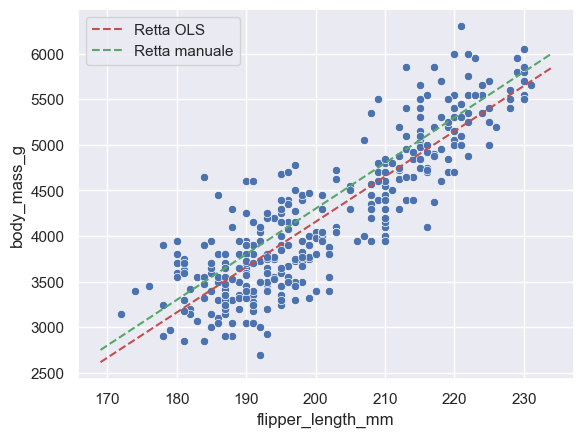

In [20]:
sns.scatterplot(x='flipper_length_mm', y='body_mass_g', data=df)

#retta calcolata con i valori trovati dal metodo OLS
axes = plt.gca()
x_vals = np.array(axes.get_xlim()) 
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='r', label='Retta OLS')
#plt.show()

#retta calcolata con valori definiti da noi
intercept2 = -5700
slope2 = 50
y_vals2 = intercept2 + slope2 * x_vals
plt.plot(x_vals, y_vals2, '--', color='g', label='Retta manuale')

plt.legend()
plt.show()

Ci siamo andati vicini, ma le due rette sono leggermente diverse.

Andiamo quindi a capire **come interpretare** il grafico: come detto la nostra **variabile target** $y$ rappresenta la `body_mass_g`, mentre la variabile predittore $x$ mostra la`flipper_length_mm`. Con il modello di regressione linare ora siamo in grado di quantificare la relazione tra le due variabili: 

$$
    \text{body mass} = -5780.83 + 49.69 \times \text{flipper length}
$$

Questo vuol dire che, quando vedremo un nuovo pinguino e ne misureremo la `flipper_length_mm`, potremo fare una stima della variabile `body_mass_g` usando la formula qui sopra.
Ad esempio: 

1. il nuovo pinguino ha una misura di `flipper_length_mm` di 205mm
2. Inseriamo il valore all'interno delle nostre due equazioni:
    1. $205 \times 49.69 = 10235.23$
    2. $10235.23 - 5780.83 = 4454.395$
3. Di conseguenza stimiamo che la variabile `body_mass_g` del nuovo pinguino sarà circa di 4405g 

<h2 style="font-family: 'Verdana'; color: lightblue;">Metodo dei minimi quadrati con librerie ad hoc</h2>

Ci sono attualmente due librerie più popolari per eseguire una regressione lineare in python:

- `scikit-learn` con il modulo `LinearRegression`; 
- `statsmodels` 

Per ora vediamo come farlo tramite `statsmodels`. I passaggi sono:

1. definire le variabili Xe Y con series panda; 
2. usare la funzione `sm.add_constant()` per aggiungere una costante (cioè l'intercetta) al modello che stiamo creando; 
3. definiamo il modello OLS passando le variabili X e Y alla funzione `sm.OLS()`; 
4. infine, richiamiamo il metodo `.fit()`, che "fitta" la linea di regressione ai nostri dati (è qui che viene fatto il calcolo di $b_0$ e $b_1$ minimizzando l'errore della funzione obiettivo)

In [21]:
import statsmodels.api as sm

Y = df['body_mass_g']
X = df['flipper_length_mm']

X = sm.add_constant(data=X)

model = sm.OLS(endog=Y,exog=X) #endog = Y = variabile dipendente, esogena = X = variabile indipendente

results = model.fit()

In [22]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):          4.37e-107
Time:                        12:33:30   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.815    -18.903      0.000   -6382.358   -5179.305
flipper_length_mm    49.6856      1.518     32.722      0.000      46.699      52.672
==============================================================================
Omnibus:                        5.634   Durbin-Watson:                   2.176
Prob(Omnibus):                  0.060   Jarque-Bera (JB):                5.585
Skew:                           0.313   Prob(JB):                       0.0613
Kurtosis:                       3.019   Cond. No.                     2.89e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.89e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<h2 style="font-family: 'Verdana'; color: lightblue;">Stime di regressione</h2>

Andando a concentrarci sulla seconda tabella e in particolare sui coefficienti della variabili, vediamo che i valori sono identici a quelli da noi calcolati. In aggiunta però abbiamo anche una serie di indicatori statistici. Ciò è corretto in quanto stiamo parlando di stime che quindi, fisiologicamente, potrebbero essere più o meno attandibili

Tali statistiche (t-statistic, p-value and confidence intervals) sono infatti state prodotte tramite un test di ipotesi dei coefficienti stimati:
$$
    \begin{align*}
    &H_0: b_1 = 0 \\
    &H_1: b_1 \neq 0
    \end{align*}
$$

L'**ipotesi nulla** afferma che **la pendenza della retta di regressione è pari zero**, ovvero che **non** c'è alcuna relazione tra le variabili in esame (graficamente, avremmo una retta orizzoantale).
L'**ipotesi alternativa** invece afferma che c'è una relazione (positiva o negativa) tra $X$ e $Y$.

La funzione `statsmodels` function usa un t-test e produce automaticamente quindi sia i p-value sia gli intervalli di confidenza delle nostre stime.
Da notare come deve essere interpretato il p-value: 

> il p-value rappresenta la probabilità di osservare un valore estremo tanto quanto o più estremo rispetto a quello osservato, assumendo che l'ipotesi nulla sia vera.

Nel nostro caso quindi, essendo tale probabilità molto vicina allo 0, è lecito supporre che ci sia una relazione tra le due variabili (cioè non accettare l'ipotesi nulla)

<h2 style="font-family: 'Verdana'; color: lightblue;">Coefficiente di determinazione</h2>

Un indicatore statistico molto importante è l'**R-quadro** ($R^2$), chiamato anche coefficiente di determinazione. tale coefficiente ci fornisce una misura della bontà di adattamento del nostro modello di regressione, in particolare esso ci indica quanta variabilità in percentuale viene spiegata dal nostro modello:

$$ 
    \begin{align*}
    R^2 &= 1 - \frac{SS_{res}}{SS_{tot}} \\
        &= 1 - \frac{\sum_{i=1}^{n}\epsilon^2}{\sum_{i=1}^{n}(y_i - \overline{y})^2}
    \end{align*}
$$

dove:
- $SS_{res}$ indica la variabilità residua, cioè la parte di variabilità non spiegata dal modello

- $SS_{tot}$ indica la variabilità totale del modello

<h2 style="font-family: 'Verdana'; color: lightblue;">Predizioni</h2>

L'obiettivo della costruzione di un modello di regressione è quello di "anticipare" il futuro e in particolare predirre i nuovi valori. In altre parole, presa in input una feature X, il modello di regressione ci permette di stimare il valore della variabile in output Y con un certo grado di accuratezza. Non a caso la libreria `statsmodels` possiede il metodo `.predict()`:

In [23]:
np.array([1, 206])

array([  1, 206])

In [24]:
results.predict(np.array([1, 206]))

array([4454.39532158])

In questo caso per ottenere una predizione passiamo un array contenente due valori:

- il moltiplicatore dell'intercetta (che nel nostro esempio è pari a $1$) $\rightarrow$ $1 \times (-5780)$
- il valore di input della variabile $X$ che andrà poi ad essere moltiplicata per il coefficiente angolare $\rightarrow$  $206 \times 49.69$ 

Mostriamo quindi graficamente la nuova predizione (punto rosso):

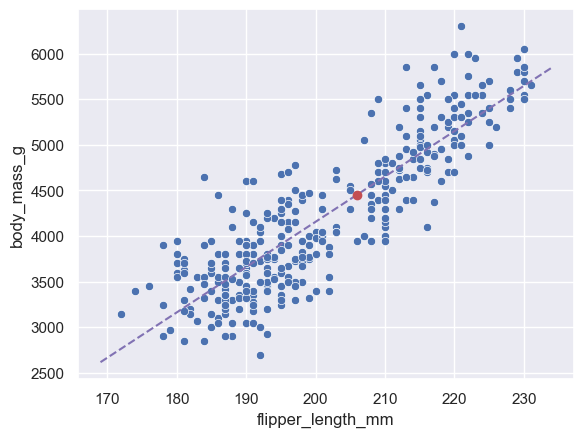

In [30]:
#ricostruiamo lo scatterplot con la retta di regressione trovata tramite OLS
sns.scatterplot(x = "flipper_length_mm", y = "body_mass_g", data = df)

axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = intercept + slope*x_vals

plt.plot(x_vals, y_vals, "--", color = "m")

#aggiungiamo il nuovo valore predetto:
plt.plot(206, results.predict(np.array([1, 206]))[0], "ro")
plt.show()

Il valore predetto, ovviamente, cade esattamente sulla retta.

Immaginiamo di avere una serie di 10 nuovi pinguini con 10 nuove misure della variabile `flipper_length_mm`. Possiamo stimare il valore della variabile `body_mass_g`.

In [ ]:
# creo le 10 nuove osservazioni usando una distribuzione normale partendo dalla media della variabile e con deviazione stanard 15
new_flipper_length_mm = np.random.normal(loc = np.mean(df.flipper_length_mm), scale = 15, size = 10)
new_flipper_length_mm

array([211.9455358 , 195.40656954, 204.21167461, 197.105429  ,
       233.56682726, 201.34627374, 195.35959502, 217.30832611,
       195.69927191, 202.07567693])

In [36]:
# ora genero le predizioni
X_new = np.column_stack((np.ones(10), new_flipper_length_mm))
results.predict(X_new)

array([4749.80263558, 3928.05472919, 4365.54136167, 4012.46352354,
       5824.06874818, 4223.17229642, 3925.72077344, 5016.25590952,
       3942.59781198, 4259.41310693])

- `np_ones(10)` crea un array di 10 elementi con valore costante 1, che serve come colonna per l’intercetta
- `np.column_stack((..., ...))` combina le due colonne (1 e x) in una matrice 10×2, che è la forma che si aspetta il modello

Concludiamo la lezione aggiungendo i valori predetti al grafico:

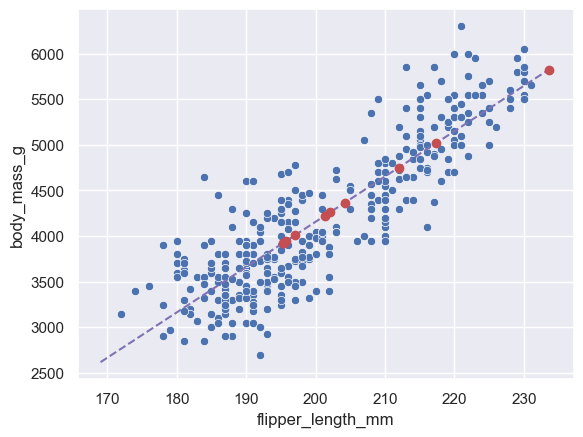

In [37]:
sns.scatterplot(x='flipper_length_mm', y='body_mass_g', data=df)

axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', color='m')

#aggiungiamo i valori predetti
y_pred = results.predict(X_new)

plt.plot(new_flipper_length_mm, y_pred, 'ro', label='Predizioni')

<h2 style="font-family: 'Verdana'; color: lightblue;">Assunzioni alla base del modello di regressione lineare</h2>

Il modello di regressione lineare possiede una serie di assunzioni che stanno alla base del modello stesso. Se queste assunzioni non sono almeno approssimativamente rispettate, non possiamo effettivamente pretendere di ottenere delle stime con un buon livello di accuratezza:

1. **Linearità**
2. **Indipendenza degli errori**
3. **Omoschedasticità degli errori**
4. **Normalità degli errori**

Partiamo subito dal primo punto. Il modello si basa sul principio che, tra le variabili X e Y, le variazioni siano proporzionali (cioè una relazione lineare, e non più che proporzionali). Se la relazione non è lineare, il modello non si adatterà bene ai dati e il rischio è chiaramente di avere delle stime lontane dai valori reali.
Gli altri tre punti hanno in comune il fatto di prendere in considerazione la componente dell'errore del modello. 
L'indipendenza degli errori tra loro serve per evitare che l'errore fatto su un'osservazione sia legato a quello fatto su un altra osservazione. Il rischio in questo caso è di creare un "effetto farfalla" dell'errore (quindi il modello non si adatta bene ai dati).
L'omoschedasticità ddegli errori richiede che la varianza dell'errore sia costante per tutti i valori di X. In altre parole, vogliamo che l'errore medio sia lo stesso sia per valori bassi sia per valori alti di X. In caso contrario, avremo delle stime molto peggiori nei valori di X con varianza più alta (quindi il modello non si adatta bene ai dati).
La normalità degli errori, infine, si traduce nel fatto che gli errori devono essere distribuiti normalmente.

In termini pratici:
- Linearità $\rightarrow$ **plot dei residui vs X**: devono avere un andamento casuale
- Indipendenza degli errori $\rightarrow$ **test Durbin-Watson** (soprattutto nelle serie temporali)
- Omoschedasticità degli errori $\rightarrow$ **plot residui vs predetti** (no forma ad imbuto) | **test Breusch-Pagan** | **test White**
- Normalità degli errori $\rightarrow$ **QQplot** | **test Shapito-Wilk**

Partiamo dalla linearità:

In [ ]:
#calcolo i valori residui
residuals = results.resid
residuals

0      537.743839
1      339.316007
2     -657.854091
4     -358.482958
5       -9.426259
          ...    
338     73.120147
340    -51.565419
341    500.635616
342    447.491280
343    597.805714
Length: 342, dtype: float64

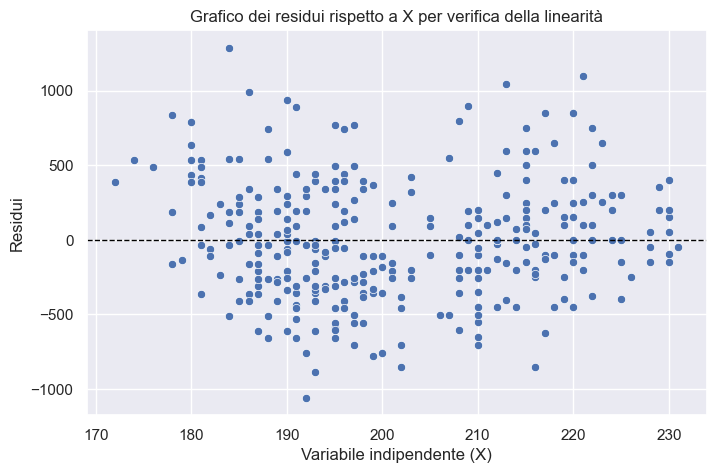

In [ ]:
#costruisco il grafico
plt.figure(figsize=(8, 5))


sns.scatterplot(x=df['flipper_length_mm'], y=residuals) #sns.residplot(x=df['flipper_length_mm'], y=df['body_mass_g'])
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel("Variabile indipendente (X)")
plt.ylabel("Residui")
plt.title("Grafico dei residui rispetto a X per verifica della linearità")

plt.show()

Da cui non risulta esserci un pattern sistematico degli errori sopra o sotto lo 0.

Passiamo ora alla omoschedasticità:

In [56]:
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

In [62]:
# Estraggo le variabili esplicative
exog = results.model.exog

In [60]:
# Test di Breusch-Pagan
bp_test = het_breuschpagan(residuals, exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']

print("Breusch-Pagan test:")
for name, val in zip(bp_labels, bp_test):
    print(f"{name}: {val:.4f}")

# Test di White
white_test = het_white(residuals, exog)
white_labels = ['Test statistic', 'p-value', 'f statistic', 'f p-value']

print("\nWhite test:")
for name, val in zip(white_labels, white_test):
    print(f"{name}: {val:.4f}")

Breusch-Pagan test:
Lagrange multiplier statistic: 2.1579
p-value: 0.1418
f-value: 2.1589
f p-value: 0.1427

White test:
Test statistic: 2.7678
p-value: 0.2506
f statistic: 1.3830
f p-value: 0.2522


Nel test di Breusch-Pagan abbiamo il seguente sistema di ipotesi:

- $H_0$: Gli errori sono omoschedastici (varianza costante).
- $H_1$: Gli errori sono eteroschedastici (varianza non costante).

In particolare il p-value è pari a circa 0.1418 (o 0.1427).

Poiché 0.1418 > 0.05, non abbiamo evidenza sufficiente per rifiutare l’ipotesi nulla di omoschedasticità.

Anche nel test di White il sistema di ipotesi è:

- $H_0$: Gli errori sono omoschedastici (varianza costante).
- $H_1$: Gli errori sono eteroschedastici (varianza non costante).

E come nell'altro caso non abbiamo evidenza sufficiente per rifiutare l’ipotesi nulla dato che 0.2506 > 0.05

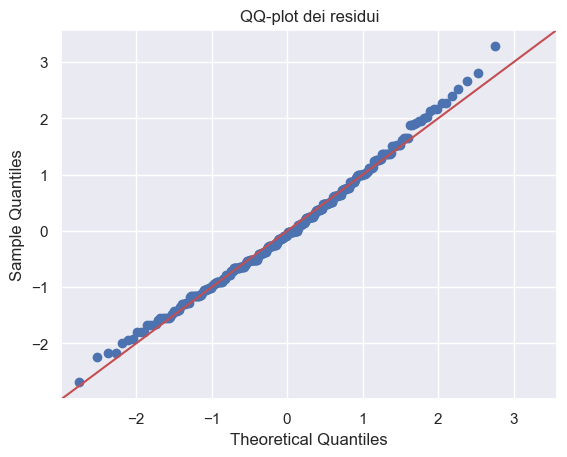

In [ ]:
# 1. QQ-plot
sm.qqplot(residuals, line = "45", fit = True)
plt.title('QQ-plot dei residui')
plt.show()

In [65]:
import scipy.stats as stats

# 2. Test di Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test statistic: {shapiro_test.statistic:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue > 0.05:
    print("Non si rifiuta l'ipotesi nulla: i residui sembrano normalmente distribuiti.")
else:
    print("Si rifiuta l'ipotesi nulla: i residui non sembrano normalmente distribuiti.")

Shapiro-Wilk test statistic: 0.9930
Shapiro-Wilk p-value: 0.1124
Non si rifiuta l'ipotesi nulla: i residui sembrano normalmente distribuiti.


Anche per quanto riguarda l'assunzione della normalità dei residui, sembra essere soddisfatta.